In [1]:
from pathlib import Path 
import pandas as pd
import geopandas as gpd

from tqdm import tqdm

In [2]:
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")

lamah_gdf = gpd.read_file(attributes_shape_path)
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

### Q

In [3]:
gauge_attr_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")
gauge_attr_df = pd.read_table(gauge_attr_path, header=0, sep=";")
gauge_attr_df.set_index("ID", inplace=True)

lamah_gdf = lamah_gdf.join(gauge_attr_df)

In [4]:
lamah_gdf.q_mean.describe()

count    846.000000
mean       1.951346
std        1.622123
min        0.081000
25%        0.793250
50%        1.473500
75%        2.764750
max       19.689000
Name: q_mean, dtype: float64

<Axes: >

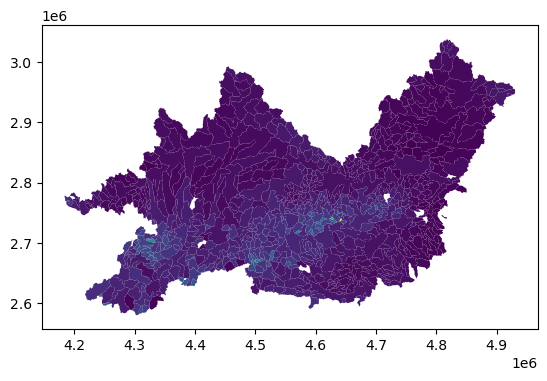

In [5]:
lamah_gdf.plot(column="Q95")

### Climate

<Axes: >

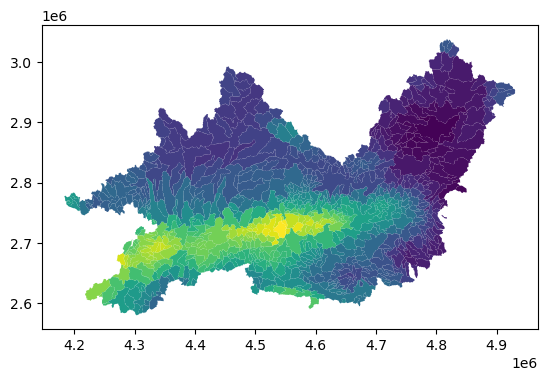

In [6]:
lamah_gdf.plot(column="p_mean")

In [7]:
lamah_gdf.p_mean.describe()

count    859.000000
mean       3.400489
std        0.999311
min        1.730000
25%        2.615000
50%        3.250000
75%        4.210000
max        5.710000
Name: p_mean, dtype: float64

In [8]:
sample_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily/ID_1.csv")
sample_df = pd.read_table(sample_path, header=0, sep=";")


In [9]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries")

file_list = list(ts_path.rglob("*.csv"))

mins = []
maxs = []
means = []

for file in tqdm(file_list):

	with open(file, "r") as f: 
		df = pd.read_table(f, header=0, sep=";")

		means.append(df["2m_temp_mean"].mean())
		mins.append(df["2m_temp_mean"].min())
		maxs.append(df["2m_temp_mean"].max())

  0%|          | 0/859 [00:00<?, ?it/s]

100%|██████████| 859/859 [00:15<00:00, 55.22it/s]


In [11]:
pd.Series(means).describe()

count    859.000000
mean       6.332433
std        3.077878
min       -4.141126
25%        4.411440
50%        7.529914
75%        8.533070
max       10.896742
dtype: float64

In [13]:
import numpy as np 
np.max(maxs)

31.5

In [ ]:
pd.Series(maxs).describe()

count    859.000000
mean      24.799651
std        3.570941
min       13.400000
25%       22.300000
50%       25.800000
75%       27.500000
max       31.500000
dtype: float64

In [ ]:
pd.Series(mins).describe()

count    859.000000
mean     -22.956112
std        2.740994
min      -31.500000
25%      -24.800000
50%      -22.500000
75%      -20.800000
max      -17.100000
dtype: float64